# Product Review Sentiment Analysis Using Pretrained Hugging Face Models

**Goal:** Compare three pretrained Hugging Face sentiment models on a small, manually-created product-review evaluation dataset.

This notebook follows the lab workflow: problem definition → data → model cards → inference → evaluation → error analysis → model comparison → recommendation.

**Important:** No model is trained from scratch in this project.


## 1. Problem Definition

**Problem:** Automatically classify product reviews as positive or negative.

**Users:** E-commerce businesses and product teams that want to understand customer satisfaction.

**Input:** A written product review.

**Output:** A sentiment label (positive/negative) and a confidence score.

**Success criteria:** Compare at least three pretrained models using Accuracy, Precision, Recall, F1-score, confusion matrices, and inference time.


In [1]:
!pip -q install transformers torch pandas scikit-learn matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("product_reviews.csv")
df.head()


,review,label
0,The product quality is excellent and it works ...,positive
1,I am very happy with this purchase and would r...,positive
2,The item looks exactly like the pictures and f...,positive
3,Great product for the price. I am satisfied wi...,positive
4,The product arrived on time and works better t...,positive


In [3]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())


Dataset shape: (100, 2)

Class distribution:
label
positive    50
negative    50
Name: count, dtype: int64


## 2. Model Selection and Model Card Investigation

We use three pretrained models:

1. **DistilBERT SST-2** — a compact English sentiment model with binary NEGATIVE/POSITIVE labels.
2. **NLP Town multilingual BERT sentiment** — specifically fine-tuned for product reviews in six languages and predicts 1–5 stars. For our binary task, 1–3 stars are mapped to negative and 4–5 stars to positive.
3. **CardiffNLP Twitter-RoBERTa sentiment** — an English sentiment model with negative/neutral/positive labels. Neutral predictions are mapped to positive for this binary evaluation; this mapping is a limitation and is discussed later.

The lab requires the custom metadata key `{'metadata':'huggingface_AI_model'}` in the pipeline output.


In [4]:
MODELS = {
    "DistilBERT-SST2": "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    "NLP-Town-Product": "nlptown/bert-base-multilingual-uncased-sentiment",
    "CardiffNLP-RoBERTa": "cardiffnlp/twitter-roberta-base-sentiment-latest",
}

MODEL_CARDS = {
    "DistilBERT-SST2": "https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    "NLP-Town-Product": "https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment",
    "CardiffNLP-RoBERTa": "https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest",
}

for name, url in MODEL_CARDS.items():
    print(name, "->", url)


DistilBERT-SST2 -> https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english
NLP-Town-Product -> https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment
CardiffNLP-RoBERTa -> https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest


### Expected model-card facts to record

- DistilBERT SST-2: English, DistilBERT architecture, binary sentiment labels, Apache-2.0 license.
- NLP Town BERT: BERT-base multilingual, product-review sentiment, six languages (English, Dutch, German, French, Italian, Spanish), MIT license, 1–5 star output.
- CardiffNLP Twitter-RoBERTa: English RoBERTa sentiment model trained for Twitter/TweetEval-style sentiment, with negative/neutral/positive labels.

Use the linked model cards above to verify and expand these details in the final report.


In [5]:
def normalize_output(model_name, raw):
    label = raw["label"].upper()
    score = float(raw["score"])

    if model_name == "NLP-Town-Product":
        # Labels are usually "1 star" ... "5 stars"
        stars = int(label.split()[0])
        final_label = "positive" if stars >= 4 else "negative"
        return {
            "label": final_label,
            "score": score,
            "raw_label": label,
            "metadata": "huggingface_AI_model"
        }

    if model_name == "CardiffNLP-RoBERTa":
        if "NEGATIVE" in label:
            final_label = "negative"
        elif "POSITIVE" in label:
            final_label = "positive"
        else:
            # Binary evaluation requires a mapping for neutral.
            final_label = "positive"
        return {
            "label": final_label,
            "score": score,
            "raw_label": label,
            "metadata": "huggingface_AI_model"
        }

    final_label = "positive" if "POSITIVE" in label else "negative"
    return {
        "label": final_label,
        "score": score,
        "raw_label": label,
        "metadata": "huggingface_AI_model"
    }


In [6]:
def run_model(model_name, model_id, texts):
    classifier = pipeline("text-classification", model=model_id)
    results = []
    start = time.perf_counter()

    for text in texts:
        raw = classifier(text, truncation=True)[0]
        results.append(normalize_output(model_name, raw))

    elapsed = time.perf_counter() - start
    return results, elapsed

all_predictions = {}
timings = {}

for name, model_id in MODELS.items():
    print(f"Running {name}...")
    preds, elapsed = run_model(name, model_id, df["review"].tolist())
    all_predictions[name] = preds
    timings[name] = elapsed
    print(f"Finished in {elapsed:.2f} seconds")


Running DistilBERT-SST2...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Finished in 2.95 seconds


In [7]:
# Verify the custom dictionary structure required by the lab
example = all_predictions["DistilBERT-SST2"][0]
print(example)
assert "metadata" in example
assert example["metadata"] == "huggingface_AI_model"


{'label': 'positive', 'score': 0.9998764991760254, 'raw_label': 'POSITIVE', 'metadata': 'huggingface_AI_model'}


In [8]:
metrics_rows = []

for name, preds in all_predictions.items():
    y_true = df["label"].values
    y_pred = [p["label"] for p in preds]

    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "Inference Time (s)": timings[name],
        "Avg Time/Review (s)": timings[name] / len(df)
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("F1", ascending=False)
metrics_df


,Model,Accuracy,Precision,Recall,F1,Inference Time (s),Avg Time/Review (s)
0,DistilBERT-SST2,1.00,1.000000,1.0,1.000000,2.183820,0.021838
1,NLP-Town-Product,0.99,0.980392,1.0,0.990099,2.254714,0.022547
2,CardiffNLP-RoBERTa,0.99,0.980392,1.0,0.990099,2.950879,0.029509


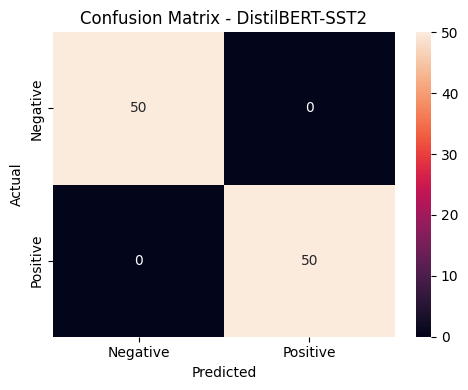

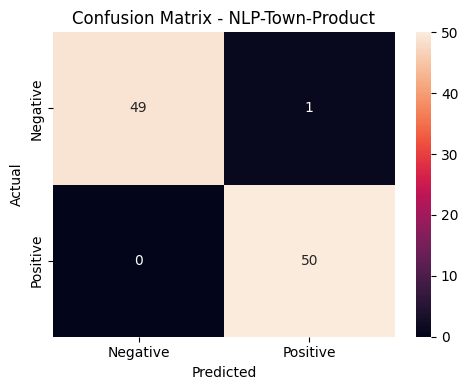

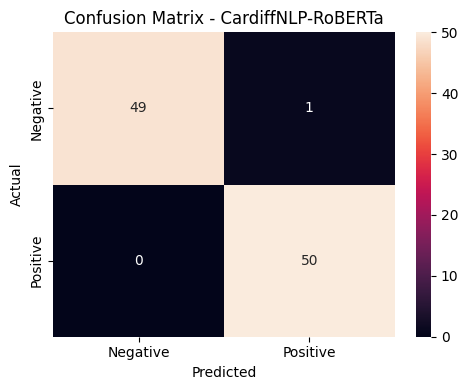

In [9]:
# Confusion matrices
figures = []

for name, preds in all_predictions.items():
    y_true = df["label"].values
    y_pred = [p["label"] for p in preds]
    cm = confusion_matrix(y_true, y_pred, labels=["negative", "positive"])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [10]:
# Add predictions to a single results table
results_df = df.copy()

for name, preds in all_predictions.items():
    short = name.replace("-", "_").replace(" ", "_")
    results_df[f"{short}_prediction"] = [p["label"] for p in preds]
    results_df[f"{short}_score"] = [p["score"] for p in preds]
    results_df[f"{short}_raw_label"] = [p["raw_label"] for p in preds]

results_df.head()


,review,label,DistilBERT_SST2_prediction,DistilBERT_SST2_score,DistilBERT_SST2_raw_label,NLP_Town_Product_prediction,NLP_Town_Product_score,NLP_Town_Product_raw_label,CardiffNLP_RoBERTa_prediction,CardiffNLP_RoBERTa_score,CardiffNLP_RoBERTa_raw_label
0,The product quality is excellent and it works ...,positive,positive,0.999876,POSITIVE,positive,0.856436,5 STARS,positive,0.978655,POSITIVE
1,I am very happy with this purchase and would r...,positive,positive,0.999843,POSITIVE,positive,0.740155,5 STARS,positive,0.987907,POSITIVE
2,The item looks exactly like the pictures and f...,positive,positive,0.999846,POSITIVE,positive,0.659366,5 STARS,positive,0.948285,POSITIVE
3,Great product for the price. I am satisfied wi...,positive,positive,0.999854,POSITIVE,positive,0.629380,5 STARS,positive,0.986649,POSITIVE
4,The product arrived on time and works better t...,positive,positive,0.999074,POSITIVE,positive,0.592162,5 STARS,positive,0.974901,POSITIVE


## 3. Error Analysis

The lab asks us to study where the pretrained models fail instead of reporting scores only.

The code below collects misclassified reviews. Select at least 10 interesting failures for the final report when the results provide enough cases.


In [11]:
error_cases = {}

for name, preds in all_predictions.items():
    temp = df.copy()
    temp["prediction"] = [p["label"] for p in preds]
    temp["score"] = [p["score"] for p in preds]
    temp["raw_label"] = [p["raw_label"] for p in preds]
    errors = temp[temp["label"] != temp["prediction"]].copy()
    error_cases[name] = errors
    print(f"\n{name}: {len(errors)} errors")
    display(errors[["review", "label", "prediction", "score", "raw_label"]].head(10))



DistilBERT-SST2: 0 errors


,review,label,prediction,score,raw_label



NLP-Town-Product: 1 errors


,review,label,prediction,score,raw_label
91,This product has made my daily routine more di...,negative,positive,0.428223,5 STARS



CardiffNLP-RoBERTa: 1 errors


,review,label,prediction,score,raw_label
87,I expected much better quality from this product.,negative,positive,0.451461,POSITIVE


### Error-analysis notes

For each selected failure, explain the likely reason. Look for:
- mixed or contradictory sentiment,
- ambiguous wording,
- negation,
- domain-specific product language,
- very short reviews,
- sarcasm,
- comparison language,
- reviews where quality and price have opposite sentiments.

Do not invent a reason without inspecting the actual review.


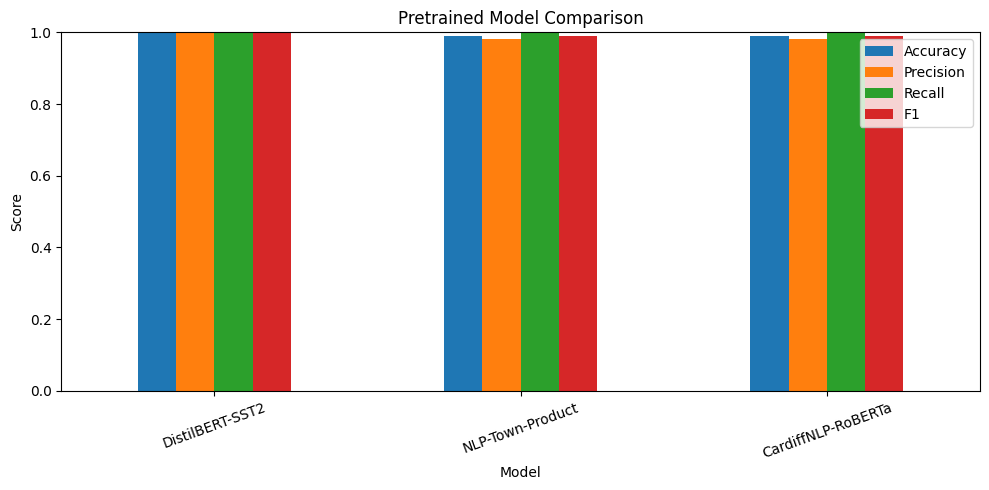

In [12]:
# Simple model comparison chart
plot_df = metrics_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]]
plot_df.plot(kind="bar", figsize=(10,5), ylim=(0,1))
plt.title("Pretrained Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [13]:
# Export results
metrics_df.to_csv("model_comparison_results.csv", index=False)
results_df.to_csv("all_model_predictions.csv", index=False)

print("Saved:")
print("- model_comparison_results.csv")
print("- all_model_predictions.csv")


Saved:
- model_comparison_results.csv
- all_model_predictions.csv


## 4. Model Recommendation

After running the notebook, choose the model using evidence from:
- F1-score and other metrics,
- inference speed,
- model size,
- training domain,
- language support,
- limitations,
- failure cases.

The winner is not automatically the model with the highest accuracy. Explain the trade-off.

### Domain Shift

Our evaluation data consists of product reviews. The NLP Town model is especially relevant because its model card states that it was fine-tuned on product reviews. The DistilBERT model was fine-tuned on SST-2, while the CardiffNLP model was built for English Twitter sentiment. This creates a useful domain-shift comparison.

### Final decision

Replace the placeholder below after running the notebook:

**Selected model:** `[WRITE MODEL NAME]`

**Why:** `[WRITE 2–4 evidence-based sentences using the actual results]`
